In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/VLM-vs-OCR-Table-Extraction-Benchmark-on-DocVQA-TableBank")
print("Working dir:", os.getcwd())

Mounted at /content/drive
Working dir: /content/drive/MyDrive/VLM-vs-OCR-Table-Extraction-Benchmark-on-DocVQA-TableBank


In [2]:
!pip install matplotlib pandas -q

In [3]:
# ─── CELL 3: load all results ───────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv("results/comparison_table.csv")
df_vlm = pd.read_csv("results/vlm_results.csv")
df_ocr = pd.read_csv("results/ocr_results_full.csv")

print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
print(df[['raw_correct','proc_correct','vlm_correct']].mean().round(3))

Columns: ['id', 'ground_truth', 'complexity', 'question_type', 'raw_correct', 'proc_correct', 'raw_time', 'proc_time', 'vlm_answer', 'vlm_correct', 'vlm_time']
Shape: (300, 11)
raw_correct     0.647
proc_correct    0.667
vlm_correct     0.770
dtype: float64


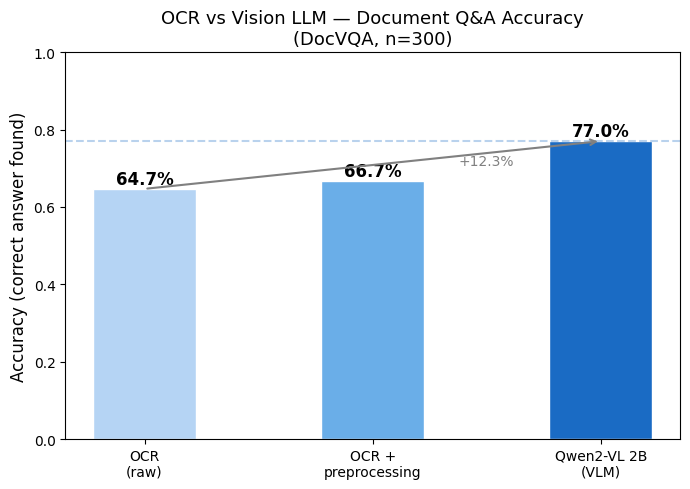

Saved.


In [4]:
# ─── CELL 4: plot 1 — overall accuracy comparison ───────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

methods = ['OCR\n(raw)', 'OCR +\npreprocessing', 'Qwen2-VL 2B\n(VLM)']
scores  = [df['raw_correct'].mean(),
           df['proc_correct'].mean(),
           df['vlm_correct'].mean()]
colors  = ['#B5D4F4', '#6AAEE8', '#1A6BC4']

bars = ax.bar(methods, scores, color=colors, width=0.45, edgecolor='white')
ax.set_ylim(0, 1.0)
ax.set_ylabel("Accuracy (correct answer found)", fontsize=12)
ax.set_title("OCR vs Vision LLM — Document Q&A Accuracy\n(DocVQA, n=300)", fontsize=13)
ax.axhline(y=scores[2], color='#1A6BC4', linestyle='--', alpha=0.3)

for bar, s in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.012,
            f"{s:.1%}", ha='center', fontsize=12, fontweight='bold')

# highlight improvement
ax.annotate('', xy=(2, scores[2]), xytext=(0, scores[0]),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.text(1.5, (scores[0]+scores[2])/2,
        f'+{scores[2]-scores[0]:.1%}', ha='center',
        fontsize=10, color='gray')

plt.tight_layout()
plt.savefig("results/figures/accuracy_comparison.png", dpi=150)
plt.show()
print("Saved.")

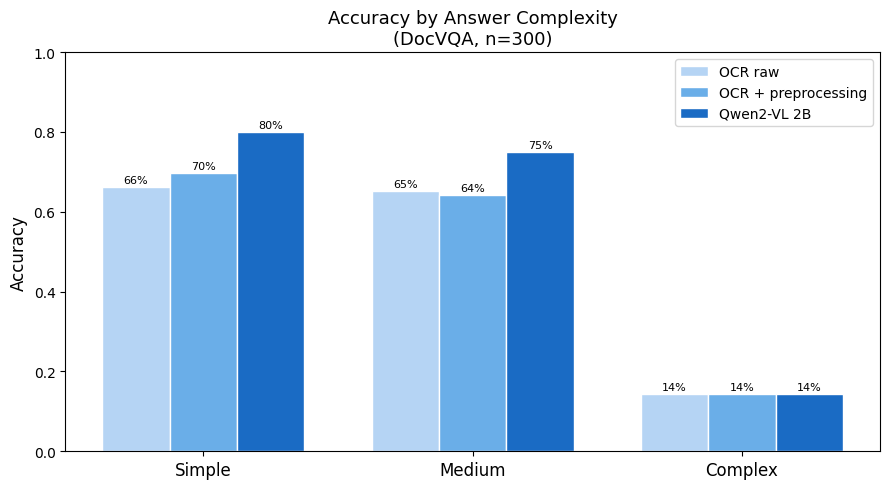

Saved.


In [5]:
# ─── CELL 5: plot 2 — accuracy by complexity ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

complexity_order = ['simple', 'medium', 'complex']
groups = df.groupby('complexity')[
    ['raw_correct','proc_correct','vlm_correct']].mean()
groups = groups.reindex(complexity_order)

x     = np.arange(len(complexity_order))
width = 0.25

b1 = ax.bar(x - width, groups['raw_correct'],  width, label='OCR raw',             color='#B5D4F4', edgecolor='white')
b2 = ax.bar(x,         groups['proc_correct'], width, label='OCR + preprocessing', color='#6AAEE8', edgecolor='white')
b3 = ax.bar(x + width, groups['vlm_correct'],  width, label='Qwen2-VL 2B',         color='#1A6BC4', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in complexity_order], fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Accuracy by Answer Complexity\n(DocVQA, n=300)", fontsize=13)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                h + 0.01, f"{h:.0%}",
                ha='center', fontsize=8)

plt.tight_layout()
plt.savefig("results/figures/accuracy_by_complexity.png", dpi=150)
plt.show()
print("Saved.")

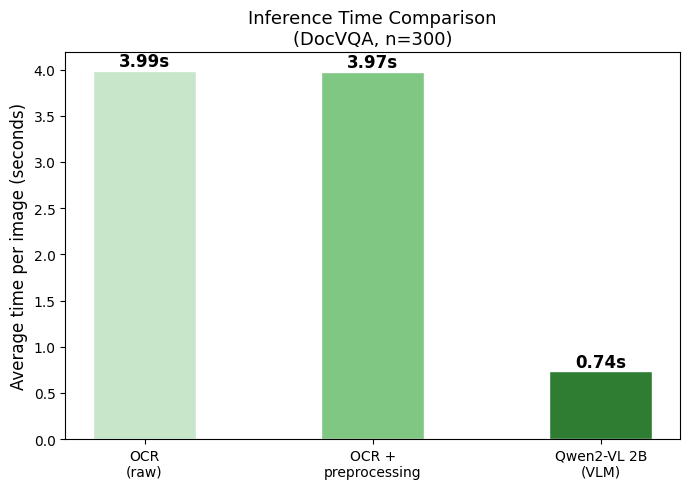

Saved.


In [6]:
# ─── CELL 6: plot 3 — runtime comparison ────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

times = [df['raw_time'].mean(),
         df['proc_time'].mean(),
         df['vlm_time'].mean()]

bars = ax.bar(methods, times,
              color=['#C8E6C9','#81C784','#2E7D32'],
              width=0.45, edgecolor='white')
ax.set_ylabel("Average time per image (seconds)", fontsize=12)
ax.set_title("Inference Time Comparison\n(DocVQA, n=300)", fontsize=13)

for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f"{t:.2f}s", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("results/figures/runtime_comparison.png", dpi=150)
plt.show()
print("Saved.")

VLM wins (VLM correct, OCR wrong): 61
OCR wins (OCR correct, VLM wrong): 30
Both correct: 170
Both wrong:   39


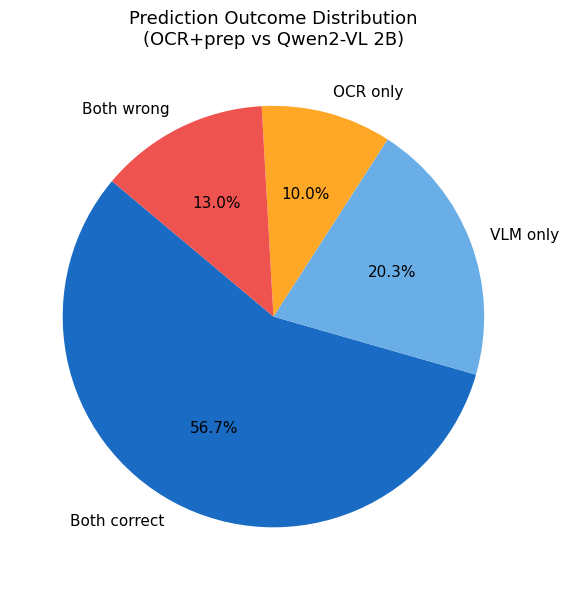

In [7]:
# ─── CELL 7: plot 4 — failure case analysis ─────────────────────────────
# where OCR fails but VLM succeeds (the interesting cases)
vlm_wins = df[(df['vlm_correct']==True)  & (df['proc_correct']==False)]
ocr_wins = df[(df['vlm_correct']==False) & (df['proc_correct']==True)]

print(f"VLM wins (VLM correct, OCR wrong): {len(vlm_wins)}")
print(f"OCR wins (OCR correct, VLM wrong): {len(ocr_wins)}")
print(f"Both correct: {len(df[(df['vlm_correct']==True) & (df['proc_correct']==True)])}")
print(f"Both wrong:   {len(df[(df['vlm_correct']==False) & (df['proc_correct']==False)])}")

# pie chart of outcome categories
labels = ['Both correct', 'VLM only', 'OCR only', 'Both wrong']
sizes  = [
    len(df[(df['vlm_correct']==True)  & (df['proc_correct']==True)]),
    len(vlm_wins),
    len(ocr_wins),
    len(df[(df['vlm_correct']==False) & (df['proc_correct']==False)])
]
colors = ['#1A6BC4','#6AAEE8','#FFA726','#EF5350']

fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 11})
ax.set_title("Prediction Outcome Distribution\n(OCR+prep vs Qwen2-VL 2B)", fontsize=13)
plt.tight_layout()
plt.savefig("results/figures/outcome_distribution.png", dpi=150)
plt.show()

In [9]:
# ─── CELL 8: print sample VLM wins for README ───────────────────────────
print("=== SAMPLE CASES WHERE VLM BEATS OCR ===\n")
for _, row in vlm_wins.head(5).iterrows():
    vlm_row = df_vlm[df_vlm['id'] == row['id']].iloc[0]
    print(f"Q:             {vlm_row['question']}")
    print(f"Ground truth:  {row['ground_truth']}")
    print(f"VLM answer:    {vlm_row['vlm_answer']}")
    print(f"Complexity:    {row['complexity']}")
    print("---")

=== SAMPLE CASES WHERE VLM BEATS OCR ===

Q:             What is name of university?
Ground truth:  university of california
VLM answer:    UNIVERSITY OF CALIFORNIA, SAN DIEGO
Complexity:    medium
---
Q:             To whom is the document sent?
Ground truth:  Paul
VLM answer:    Paul
Complexity:    simple
---
Q:             What time is the ‘coffee break’?
Ground truth:  11:14 to 11:39 a.m.
VLM answer:    11:14 to 11:39 a.m.
Complexity:    medium
---
Q:             What is the name of the choco fills advertised?
Ground truth:  dark fantasy
VLM answer:    Dark Fantasy
Complexity:    simple
---
Q:             What time is ‘question and answers ‘session?
Ground truth:  12:25 to 12:58 p.m.
VLM answer:    12:25 to 12:58 p.m.
Complexity:    medium
---


In [10]:
# ─── CELL 9: save final summary stats ───────────────────────────────────
summary = {
    'method':   ['OCR raw', 'OCR + preprocessing', 'Qwen2-VL 2B'],
    'accuracy': [round(df['raw_correct'].mean(), 3),
                 round(df['proc_correct'].mean(), 3),
                 round(df['vlm_correct'].mean(), 3)],
    'avg_time': [round(df['raw_time'].mean(), 2),
                 round(df['proc_time'].mean(), 2),
                 round(df['vlm_time'].mean(), 2)]
}
pd.DataFrame(summary).to_csv("results/final_summary.csv", index=False)
print(pd.DataFrame(summary))

                method  accuracy  avg_time
0              OCR raw     0.647      3.99
1  OCR + preprocessing     0.667      3.97
2          Qwen2-VL 2B     0.770      0.74
